In [11]:
# ============================================================
# CELL 0: Install missing packages (run once per session)
# ============================================================
!pip install tslearn dtaidistance sktime -q

print("Installations complete.")

Installations complete.


In [12]:
# ============================================================
# CELL 1: Imports & configuration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import skew, kurtosis, entropy
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.impute import SimpleImputer
from tslearn.metrics import cdist_dtw
from tslearn.clustering import TimeSeriesKMeans
from sktime.transformations.panel.rocket import MiniRocket
import warnings
warnings.filterwarnings('ignore')

# Settings
SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

SIGNAL_COLS = ['X','Y','Z','enmo','anglez','light','battery_voltage']
ENMO_IDX = SIGNAL_COLS.index('enmo')
ANGLEZ_IDX = SIGNAL_COLS.index('anglez')
CLUSTER_COLORS = ['steelblue','tomato','forestgreen','orange','purple']

print("All imports successful.")

All imports successful.


In [13]:
# ============================================================
# CELL 2: Load your data (no meta_train.csv needed)
# ============================================================
X_train_raw = np.load("X_train_raw.npy").astype(np.float64)   # (N, 200, 7)
X_train_paa = np.load("X_train_paa.npy").astype(np.float64)   # (N, 20, 7)
y_train = np.load("y_train.npy")                               # (N,)

print(f"Raw data shape: {X_train_raw.shape}")
print(f"PAA data shape: {X_train_paa.shape}")
print(f"Labels shape : {y_train.shape}")
print(f"Class distribution: 0: {np.sum(y_train==0)}, 1: {np.sum(y_train==1)}")

Raw data shape: (3355, 200, 7)
PAA data shape: (3355, 20, 7)
Labels shape : (3355,)
Class distribution: 0: 2192, 1: 1163


In [14]:
# ============================================================
# CELL 3: Preprocessing – Z‑score per subject/channel
# ============================================================
def zscore_per_ts(data):
    """data: (n_samples, timesteps, channels) -> z‑score along time axis"""
    mu = data.mean(axis=1, keepdims=True)
    std = data.std(axis=1, keepdims=True) + 1e-8
    return (data - mu) / std

# Z‑score full raw and PAA
X_raw_z = zscore_per_ts(X_train_raw)
X_paa_z = zscore_per_ts(X_train_paa)

print("Z‑scoring done.")

Z‑scoring done.


In [15]:
# ============================================================
# CELL 4: Extract statistical features (full dataset)
# ============================================================
def extract_stat_features(data):
    N, T, C = data.shape
    rows = []
    for i in range(N):
        feats = {}
        for j, col in enumerate(SIGNAL_COLS):
            x = data[i, :, j]
            feats[f"{col}_mean"] = np.mean(x)
            feats[f"{col}_std"]  = np.std(x)
            feats[f"{col}_min"]  = np.min(x)
            feats[f"{col}_max"]  = np.max(x)
            feats[f"{col}_skew"] = skew(x)
            feats[f"{col}_kurt"] = kurtosis(x)
        # Additional enmo summaries
        enmo = data[i, :, ENMO_IDX]
        feats["enmo_median"] = np.median(enmo)
        feats["enmo_q25"]    = np.percentile(enmo, 25)
        feats["enmo_q75"]    = np.percentile(enmo, 75)
        rows.append(feats)
    df = pd.DataFrame(rows)
    # Impute any potential NaNs (should be none)
    imp = SimpleImputer(strategy="median")
    arr = imp.fit_transform(df.values)
    return arr, df.columns.tolist()

stat_feat_arr, stat_feat_names = extract_stat_features(X_raw_z)
scaler = StandardScaler()
stat_feat_scaled = scaler.fit_transform(stat_feat_arr)

print(f"Statistical features shape: {stat_feat_scaled.shape}")

Statistical features shape: (3355, 45)


In [16]:
# ============================================================
# CELL 5: Balanced subsample for DTW methods
# ============================================================
idx0 = np.where(y_train == 0)[0]
idx1 = np.where(y_train == 1)[0]
n_per_class = 300
sub_idx = np.concatenate([
    np.random.choice(idx0, n_per_class, replace=False),
    np.random.choice(idx1, n_per_class, replace=False)
])
np.random.shuffle(sub_idx)

y_dtw = y_train[sub_idx]
raw_dtw = X_raw_z[sub_idx][:, :, [ENMO_IDX, ANGLEZ_IDX]]   # (600, 200, 2)
print(f"DTW subsample shape: {raw_dtw.shape}, class balance: {np.bincount(y_dtw)}")

DTW subsample shape: (600, 200, 2), class balance: [300 300]


In [17]:
# ============================================================
# CELL 6: Precomputed DTW distance matrix (600x600)
# ============================================================
print("Computing DTW distance matrix (this may take 1‑2 minutes)...")
dtw_dist = cdist_dtw(raw_dtw, global_constraint='sakoe_chiba', sakoe_chiba_radius=5)
np.fill_diagonal(dtw_dist, 0)
print("DTW distance matrix ready.")

Computing DTW distance matrix (this may take 1‑2 minutes)...
DTW distance matrix ready.


In [18]:
# ============================================================
# CELL 7: Helper function for metrics
# ============================================================
def clustering_metrics(name, labels, X=None, dist_matrix=None, true_labels=None):
    if dist_matrix is not None:
        sil = silhouette_score(dist_matrix, labels, metric='precomputed')
        db = np.nan
    else:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
    ari = adjusted_rand_score(true_labels, labels) if true_labels is not None else np.nan
    ami = adjusted_mutual_info_score(true_labels, labels) if true_labels is not None else np.nan
    print(f"{name}: sil={sil:.4f}, DB={db:.4f if not np.isnan(db) else 'NaN'}, ARI={ari:.4f}, AMI={ami:.4f}")
    return {'name':name, 'silhouette':sil, 'DB':db, 'ARI':ari, 'AMI':ami}

all_metrics = []

In [19]:
# ============================================================
# CLUSTERING METRICS FUNCTION (FIXED VERSION)
# Replace your OLD clustering_metrics() function with this
# ============================================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    adjusted_mutual_info_score
)

import numpy as np


def clustering_metrics(name, labels, X=None, dist_matrix=None, true_labels=None):

    labels = np.asarray(labels)

    # ── Handle invalid clustering cases ──────────────────────
    if len(np.unique(labels)) < 2:
        sil = np.nan
        db = np.nan

    else:

        # For DTW / precomputed distance matrix
        if dist_matrix is not None:
            sil = silhouette_score(
                dist_matrix,
                labels,
                metric='precomputed'
            )

            # Davies-Bouldin does not support precomputed distances
            db = np.nan

        # Standard Euclidean features
        else:
            sil = silhouette_score(X, labels)

            db = davies_bouldin_score(
                X,
                labels
            )

    # ── External validation ──────────────────────────────────
    ari = (
        adjusted_rand_score(true_labels, labels)
        if true_labels is not None else np.nan
    )

    ami = (
        adjusted_mutual_info_score(true_labels, labels)
        if true_labels is not None else np.nan
    )

    # ── Safe DB formatting ───────────────────────────────────
    db_str = f"{db:.4f}" if not np.isnan(db) else "NaN"

    # ── Print metrics ────────────────────────────────────────
    print(
        f"{name}: "
        f"sil={sil:.4f}, "
        f"DB={db_str}, "
        f"ARI={ari:.4f}, "
        f"AMI={ami:.4f}"
    )

    # ── Return dictionary ────────────────────────────────────
    return {
        'name': name,
        'silhouette': sil,
        'DB': db,
        'ARI': ari,
        'AMI': ami
    }

DTW K‑Means: sil=0.0135, DB=NaN, ARI=0.0025, AMI=0.0023


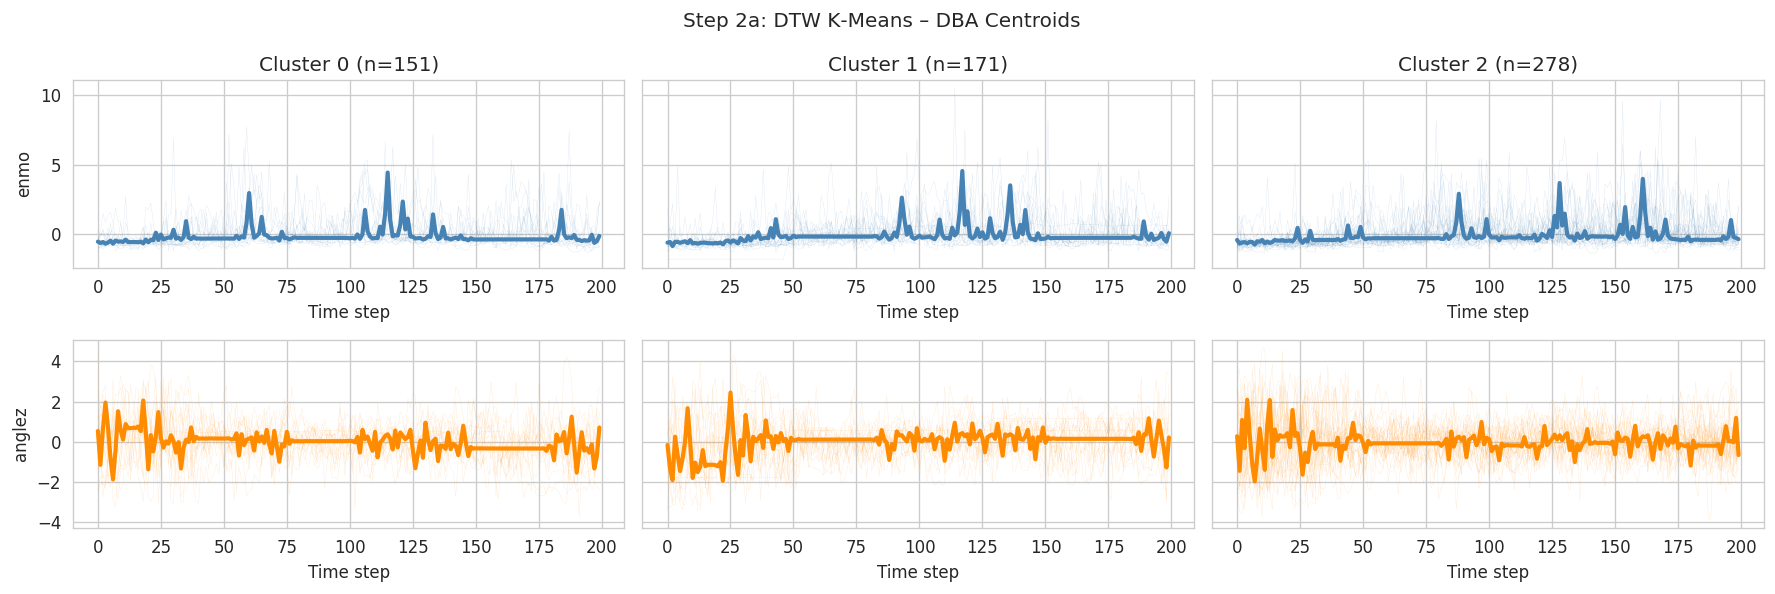

In [ ]:
# ============================================================
# CELL 9: Step 2a – DTW K‑Means (Sakoe‑Chiba)
# ============================================================
km_dtw = TimeSeriesKMeans(n_clusters=K, metric='dtw',
                          metric_params={'global_constraint':'sakoe_chiba','sakoe_chiba_radius':5},
                          random_state=SEED, n_init=5, max_iter=10)
labels_dtw_km = km_dtw.fit_predict(raw_dtw)

m2a = clustering_metrics("DTW K‑Means", labels_dtw_km, dist_matrix=dtw_dist, true_labels=y_dtw)
all_metrics.append(m2a)

# DBA centroids
centroids = km_dtw.cluster_centers_  # (K, 200, 2)
t_full = np.arange(200)
fig, axes = plt.subplots(2, K, figsize=(5*K, 5), sharey='row')
for c in range(K):
    mask = labels_dtw_km == c
    for ch, (ch_name, color) in enumerate([('enmo','steelblue'),('anglez','darkorange')]):
        # Plot individual subjects (thin, transparent)
        for ts in raw_dtw[mask][::10]:
            axes[ch, c].plot(t_full, ts[:, ch], color=color, lw=0.2, alpha=0.2)
        # DBA centroid
        axes[ch, c].plot(t_full, centroids[c, :, ch], color=color, lw=2.5, label='DBA')
        if ch == 0: axes[ch, c].set_title(f'Cluster {c} (n={mask.sum()})')
        if c == 0: axes[ch, c].set_ylabel(ch_name)
        axes[ch, c].set_xlabel('Time step')
plt.suptitle("Step 2a: DTW K‑Means – DBA Centroids")
plt.tight_layout()
plt.show()

DTW Hierarchical: sil=0.1536, DB=NaN, ARI=-0.0000, AMI=-0.0042


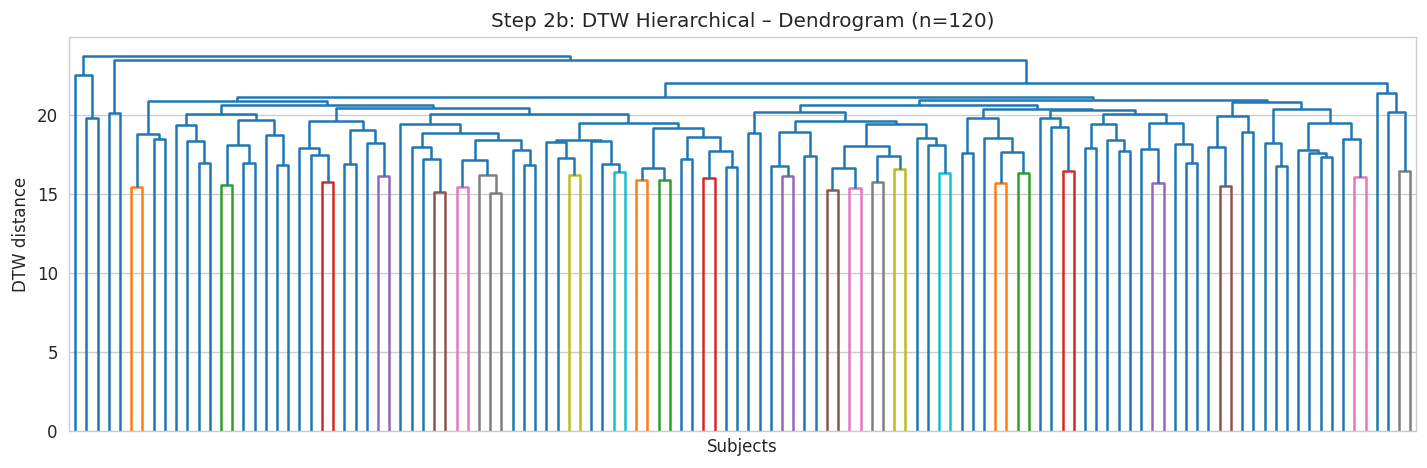

In [ ]:
# ============================================================
# CELL 10: Step 2b – DTW Hierarchical (average linkage)
# ============================================================
hc_dtw = AgglomerativeClustering(n_clusters=K, metric='precomputed', linkage='average')
labels_dtw_hc = hc_dtw.fit_predict(dtw_dist)

m2b = clustering_metrics("DTW Hierarchical", labels_dtw_hc, dist_matrix=dtw_dist, true_labels=y_dtw)
all_metrics.append(m2b)

# Dendrogram sample
sample_idx = np.random.choice(len(raw_dtw), 120, replace=False)
dist_sample = dtw_dist[np.ix_(sample_idx, sample_idx)]
condensed = dist_sample[np.triu_indices(120, k=1)]
Z = linkage(condensed, method='average')
plt.figure(figsize=(12, 4))
dendrogram(Z, no_labels=True, color_threshold=0.7*max(Z[:,2]))
plt.title("Step 2b: DTW Hierarchical – Dendrogram (n=120)")
plt.xlabel("Subjects"); plt.ylabel("DTW distance")
plt.tight_layout()
plt.show()

Features+Ward: sil=0.8907, DB=0.5557, ARI=0.0008, AMI=-0.0001


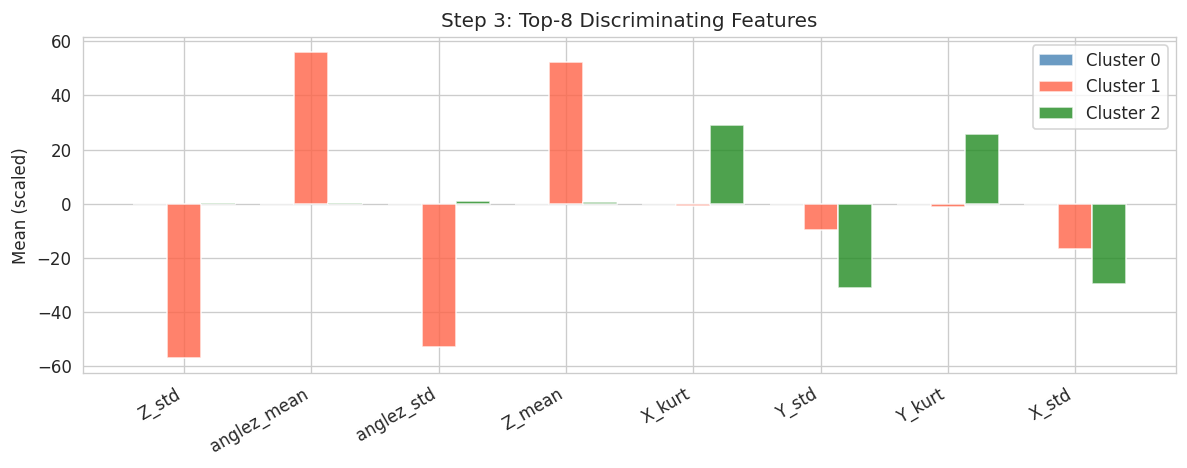

In [ ]:
# ============================================================
# CELL 11: Step 3 – Statistical Features + Hierarchical Ward
# ============================================================
hc_ward = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_feat = hc_ward.fit_predict(stat_feat_scaled)

m3 = clustering_metrics("Features+Ward", labels_feat, X=stat_feat_scaled, true_labels=y_train)
all_metrics.append(m3)

# Top discriminating features
feat_df = pd.DataFrame(stat_feat_scaled, columns=stat_feat_names)
feat_df['cluster'] = labels_feat
cluster_means = feat_df.groupby('cluster').mean()
top_feats = cluster_means.var(axis=0).nlargest(8).index.tolist()
plt.figure(figsize=(10, 4))
x = np.arange(len(top_feats))
width = 0.8 / K
for c in range(K):
    plt.bar(x + c*width, cluster_means.loc[c, top_feats], width=width,
            label=f'Cluster {c}', color=CLUSTER_COLORS[c], alpha=0.8)
plt.xticks(x + width*(K-1)/2, top_feats, rotation=30, ha='right')
plt.ylabel("Mean (scaled)"); plt.title("Step 3: Top‑8 Discriminating Features")
plt.legend(); plt.tight_layout(); plt.show()

ROCKET features shape: (3355, 19992)
After PCA: (3355, 50), explained variance: 0.796
ROCKET+PCA: sil=0.0907, DB=2.5018, ARI=-0.0037, AMI=0.0065


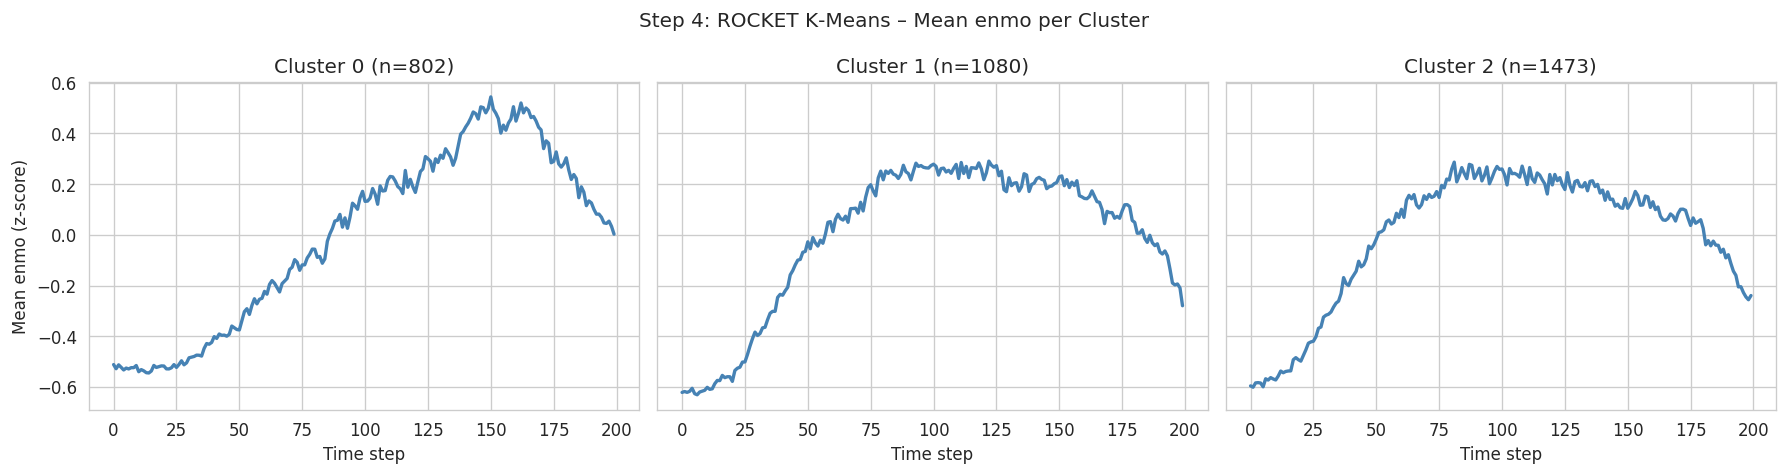

In [ ]:
# ============================================================
# CELL 12: Step 4 – ROCKET + PCA + K‑Means
# ============================================================
# Use raw enmo+anglez, shape (N, channels, timesteps) for sktime
rocket_input = X_raw_z[:, :, [ENMO_IDX, ANGLEZ_IDX]].transpose(0, 2, 1).astype(np.float32)
rocket = MiniRocket(random_state=SEED)   # faster than full Rocket
rocket_feats = rocket.fit_transform(rocket_input)   # (N, ~10k)
print(f"ROCKET features shape: {rocket_feats.shape}")

# PCA to 50 components
pca_rocket = PCA(n_components=50, random_state=SEED)
rocket_pca = pca_rocket.fit_transform(rocket_feats)
print(f"After PCA: {rocket_pca.shape}, explained variance: {pca_rocket.explained_variance_ratio_.sum():.3f}")

km_rocket = KMeans(n_clusters=K, random_state=SEED, n_init=10)
labels_rocket = km_rocket.fit_predict(rocket_pca)

m4 = clustering_metrics("ROCKET+PCA", labels_rocket, X=rocket_pca, true_labels=y_train)
all_metrics.append(m4)

# Mean enmo per ROCKET cluster
fig, axes = plt.subplots(1, K, figsize=(5*K, 4), sharey=True)
for c in range(K):
    mask = labels_rocket == c
    mean_enmo = X_raw_z[mask, :, ENMO_IDX].mean(axis=0)
    axes[c].plot(np.arange(200), mean_enmo, color='steelblue', lw=2)
    axes[c].set_title(f'Cluster {c} (n={mask.sum()})')
    axes[c].set_xlabel('Time step')
    if c==0: axes[c].set_ylabel('Mean enmo (z‑score)')
plt.suptitle("Step 4: ROCKET K‑Means – Mean enmo per Cluster")
plt.tight_layout(); plt.show()